In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_excel("C:/Users/HP/Desktop/excel files/BlinkIT Grocery Data.xlsx")

### checking raw data ###

In [8]:
df.info()
df.duplicated().sum()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

In [10]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat', 'low fat', 'LF', 'reg'], dtype=object)

### Transforming data ###

In [11]:
df.columns=df.columns.str.replace(" ","_").str.lower()

In [13]:
df['item_fat_content']=df['item_fat_content'].replace({
    'LF':'Low Fat',
    'low fat':'Low Fat',
    'reg':'Regular'
})

In [15]:
df['item_fat_content'].unique()

array(['Regular', 'Low Fat'], dtype=object)

In [16]:
df=df.drop(['item_visibility','item_weight'],axis=1)

In [17]:
df['outlet_establishment_year'].unique()

array([2012, 2022, 2016, 2014, 2015, 2020, 2011, 2018, 2017])

In [21]:
df.columns

Index(['item_fat_content', 'item_identifier', 'item_type',
       'outlet_establishment_year', 'outlet_identifier',
       'outlet_location_type', 'outlet_size', 'outlet_type', 'sales',
       'rating'],
      dtype='object')

In [22]:
df.head(5)

,item_fat_content,item_identifier,item_type,outlet_establishment_year,outlet_identifier,outlet_location_type,outlet_size,outlet_type,sales,rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,55.1614,5.0


### data insights ###


In [19]:
#1.Total sales by item type

Total_sales=df.groupby('item_type')['sales'].sum().sort_values(ascending=False)
print(Total_sales)

item_type
Fruits and Vegetables    178124.0810
Snack Foods              175433.9224
Household                135976.5254
Frozen Foods             118558.8814
Dairy                    101276.4616
Canned                    90706.7290
Baking Goods              81894.7364
Health and Hygiene        68025.8388
Meat                      59449.8638
Soft Drinks               58514.1670
Breads                    35379.1198
Hard Drinks               29334.6806
Others                    22451.8916
Starchy Foods             21880.0274
Breakfast                 15596.6966
Seafood                    9077.8700
Name: sales, dtype: float64


In [20]:
#2.Top 5 most selling items

Top_items=df.groupby('item_identifier')['sales'].sum().sort_values(ascending=False).head(5)
print(Top_items)

item_identifier
FDU12    2371.0112
FDT07    2306.8970
NCQ06    2294.7126
FDL58    2111.6544
NCB31    2104.7280
Name: sales, dtype: float64


In [24]:
#3 Avg sales by outlet type

avg_sales_outlet=df.groupby('outlet_type')['sales'].mean()
print(avg_sales_outlet)

outlet_type
Grocery Store        140.294690
Supermarket Type1    141.213895
Supermarket Type2    141.678638
Supermarket Type3    139.801791
Name: sales, dtype: float64


In [25]:
#4.total sales by yearly

yearly_sales=df.groupby('outlet_establishment_year')['sales'].sum()
print(yearly_sales)

outlet_establishment_year
2011     78131.5666
2012    130476.8598
2014    131809.0156
2015    130942.7802
2016    132113.3698
2017    133103.9070
2018    204522.2570
2020    129103.9604
2022    131477.7764
Name: sales, dtype: float64


In [30]:
# 5. Outlets with above-average sales
avg_sales = df['sales'].mean()
below_avg_outlets = df.groupby('outlet_identifier')['sales'].sum()
below_avg_outlets = below_avg_outlets[below_avg_outlets > avg_sales]
print(below_avg_outlets)

outlet_identifier
OUT010     78131.5666
OUT013    131809.0156
OUT017    129103.9604
OUT018    131477.7764
OUT019     73807.5824
OUT027    130714.6746
OUT035    133103.9070
OUT045    130942.7802
OUT046    132113.3698
OUT049    130476.8598
Name: sales, dtype: float64


In [33]:
# 6. Items with same name but different fat content
duplicates = df.groupby(['item_identifier', 'item_fat_content']).size().reset_index().groupby('item_identifier').size()
multiple_fats = duplicates[duplicates >1]
print(multiple_fats)

Series([], dtype: int64)


### charts ###

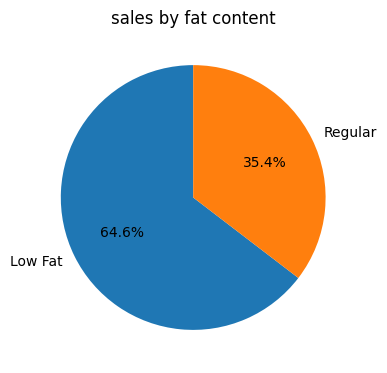

In [36]:
# Total sales by fat_content

sales_by_fat=df.groupby('item_fat_content')['sales'].sum()

plt.figure(figsize=(4,4))
plt.pie(sales_by_fat,labels=sales_by_fat.index,autopct='%.1f%%',startangle=90)
plt.title('sales by fat content')
plt.tight_layout()
plt.show()

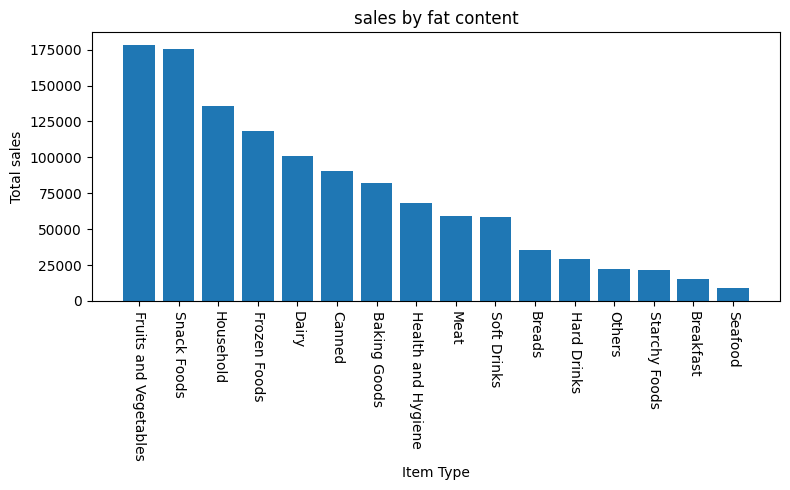

In [37]:
#total sales by item type

sales_by_type=df.groupby('item_type')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
bars=plt.bar(sales_by_type.index, sales_by_type.values)

plt.xticks(rotation=-90)
plt.title('sales by fat content')
plt.xlabel('Item Type')
plt.ylabel('Total sales')
plt.tight_layout()
plt.show()

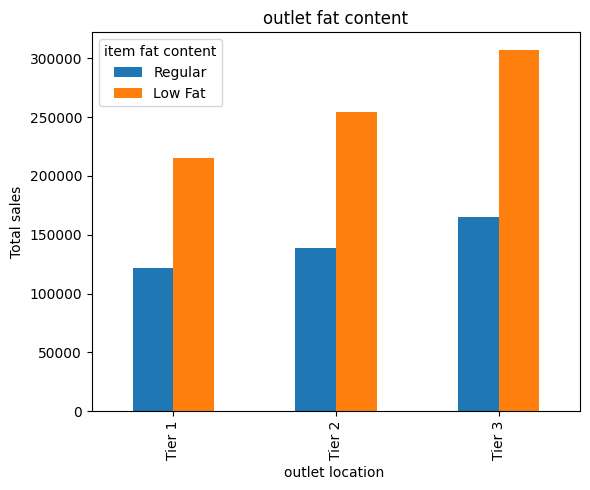

In [38]:
# fat content by outlet for total sales

grouped=df.groupby(['outlet_location_type','item_fat_content'])['sales'].sum().unstack()
grouped=grouped[['Regular','Low Fat']]

axis=grouped.plot(kind='bar',figsize=(6,5))
plt.title('outlet fat content')
plt.xlabel('outlet location ')
plt.ylabel('Total sales')
plt.legend(title='item fat content')
plt.tight_layout()
plt.show()

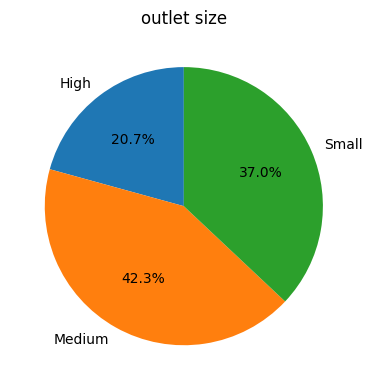

In [39]:
# total sales by outlet size content

sales_by_size=df.groupby('outlet_size')['sales'].sum()

plt.figure(figsize=(4,4))
plt.pie(sales_by_size, labels=sales_by_size.index ,autopct='%.1f%%',startangle=90)
plt.title('outlet size')
plt.tight_layout()
plt.show()

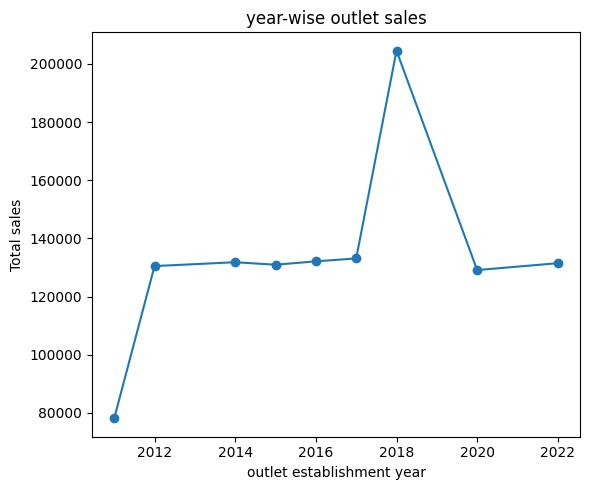

In [40]:
# total sales by outlest establishment year wise

sales_by_year=df.groupby('outlet_establishment_year')['sales'].sum().sort_index()

plt.figure(figsize=(6,5))
plt.plot(sales_by_year.index, sales_by_year.values , marker='o')

plt.title('year-wise outlet sales')
plt.xlabel('outlet establishment year')
plt.ylabel('Total sales')
plt.tight_layout()
plt.show()